# 🍷 Wine Type Classification: ML for Food Authentication & Biosecurity

**Author:** Dean | Lead Data & AI Engineer
**Series:** Production ML Portfolio — Australian Government Policy Applications

## Government Context
- **FSANZ** — Wine standards, food fraud prevention
- **Wine Australia** — Export compliance, Geographic Indication protection
- **DAFF** — Biosecurity, import screening
- **ATO** — Wine Equalisation Tax compliance
- **ACCC** — Misleading labelling, consumer protection

Dataset: sklearn built-in wine — NO dataset needed. 178 samples, 13 features, 3 classes.

---

## 1. Data Loading

In [1]:
import warnings,time,numpy as np,pandas as pd,matplotlib.pyplot as plt,seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score,f1_score,classification_report,confusion_matrix,cohen_kappa_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
warnings.filterwarnings('ignore');plt.style.use('seaborn-v0_8-whitegrid')
data=load_wine();df=pd.DataFrame(data.data,columns=data.feature_names)
df['target']=data.target;tl=list(data.target_names)
print(f"Loaded sklearn wine: {df.shape[0]:,} x {df.shape[1]}")
for i,col in enumerate(df.columns):
    print(f"  {i:2d}. {col:25s} | uniq={df[col].nunique()}")
df.head()

Loaded sklearn wine: 178 x 14
   0. alcohol                   | uniq=126
   1. malic_acid                | uniq=133
   2. ash                       | uniq=79
   3. alcalinity_of_ash         | uniq=63
   4. magnesium                 | uniq=53
   5. total_phenols             | uniq=97
   6. flavanoids                | uniq=132
   7. nonflavanoid_phenols      | uniq=39
   8. proanthocyanins           | uniq=101
   9. color_intensity           | uniq=132
  10. hue                       | uniq=78
  11. od280/od315_of_diluted_wines | uniq=122
  12. proline                   | uniq=121
  13. target                    | uniq=3


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


## 2. Target

Target: target
target
0    59
1    71
2    48
Name: count, dtype: int64


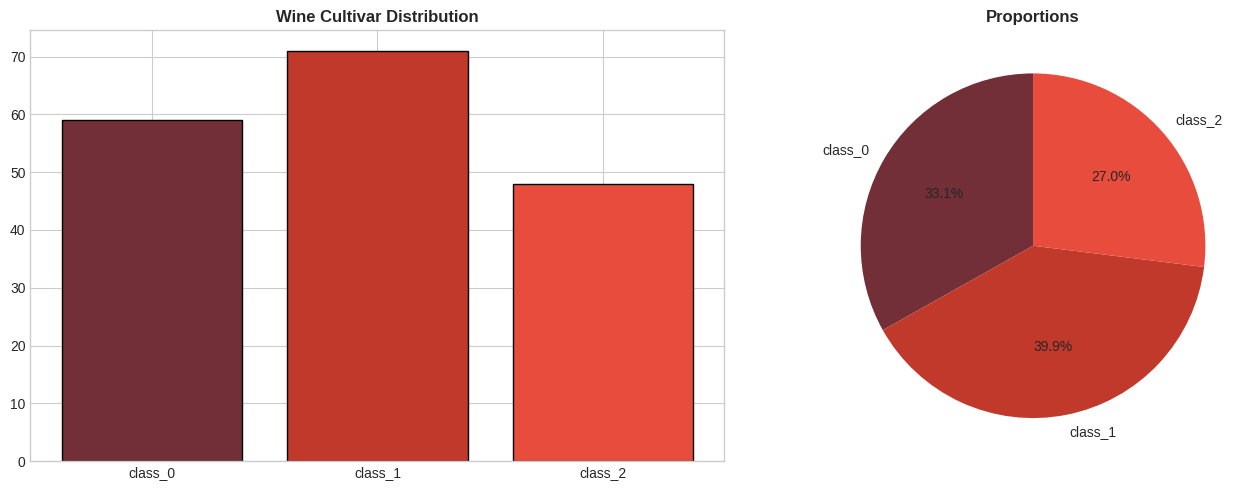

AU: Wine is a $45B industry. Wine Australia regulates export & labelling.


In [2]:
tc='target';nc=3
print(f"Target: {tc}");print(df[tc].value_counts().sort_index())
fig,axes=plt.subplots(1,2,figsize=(14,5))
vc=df[tc].value_counts().sort_index();colors=['#722f37','#c0392b','#e74c3c']
axes[0].bar(range(3),vc.values,color=colors,edgecolor='black')
axes[0].set_xticks(range(3));axes[0].set_xticklabels(tl)
axes[0].set_title('Wine Cultivar Distribution',fontweight='bold')
axes[1].pie(vc.values,labels=tl,autopct='%1.1f%%',colors=colors,startangle=90)
axes[1].set_title('Proportions',fontweight='bold')
plt.tight_layout();plt.savefig('target.png',dpi=150);plt.show()
print("AU: Wine is a $45B industry. Wine Australia regulates export & labelling.")

## 3. EDA

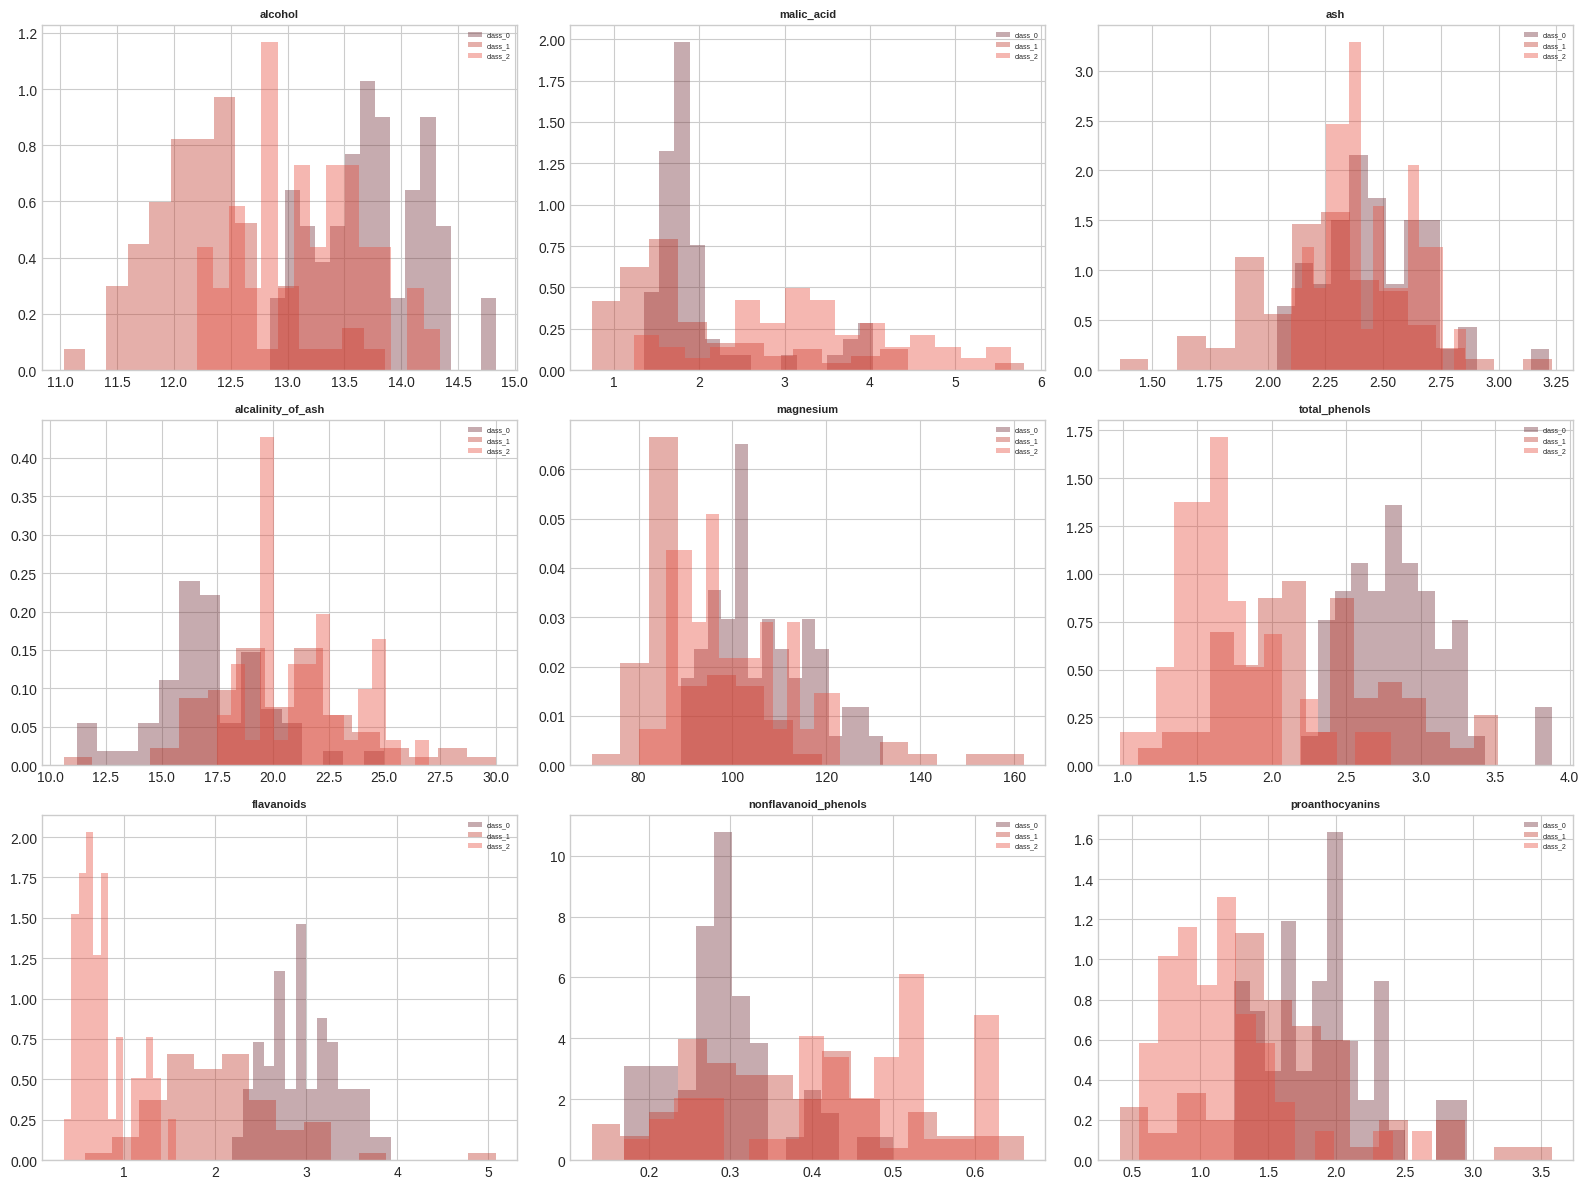

In [3]:
nums=[c2 for c2 in df.columns if c2!=tc]
fig,axes=plt.subplots(3,3,figsize=(16,12));axes=axes.flatten()
for i,col in enumerate(nums[:9]):
    for cv in range(3):
        s=df[df[tc]==cv][col]
        axes[i].hist(s,bins=15,alpha=0.4,label=tl[cv],density=True,color=colors[cv])
    axes[i].set_title(col[:20],fontsize=8,fontweight='bold');axes[i].legend(fontsize=5)
for j in range(i+1,len(axes)):axes[j].set_visible(False)
plt.tight_layout();plt.savefig('eda.png',dpi=150);plt.show()

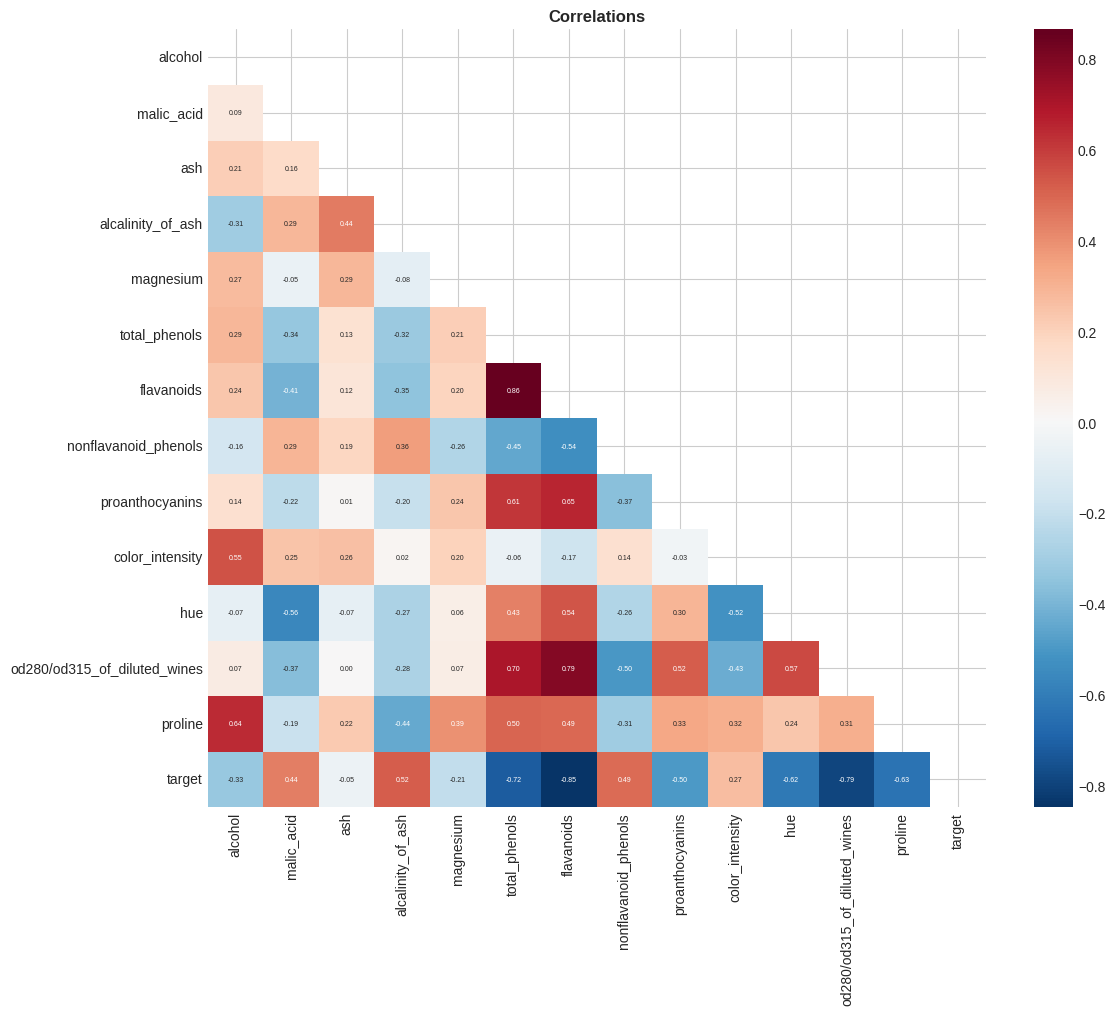

In [4]:
corr=df.corr()
fig,ax=plt.subplots(figsize=(12,10))
sns.heatmap(corr,mask=np.triu(np.ones_like(corr,dtype=bool)),annot=True,fmt='.2f',cmap='RdBu_r',center=0,square=True,ax=ax,annot_kws={'size':5})
ax.set_title('Correlations',fontweight='bold')
plt.tight_layout();plt.savefig('corr.png',dpi=150);plt.show()

## 4. Preprocessing

In [5]:
X=df[nums].copy();y=df[tc].values
print(f"X: {X.shape}, classes: {np.unique(y)}")

X: (178, 13), classes: [0 1 2]


## 5. Training

In [6]:
try:
    from xgboost import XGBClassifier
except: XGBClassifier=None
try:
    from lightgbm import LGBMClassifier
except: LGBMClassifier=None
models={'LogReg':LogisticRegression(max_iter=2000,random_state=42,multi_class='multinomial'),
        'RF':RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)}
if XGBClassifier: models['XGB']=XGBClassifier(n_estimators=100,random_state=42,eval_metric='mlogloss',use_label_encoder=False,verbosity=0,n_jobs=-1)
if LGBMClassifier: models['LGBM']=LGBMClassifier(n_estimators=100,random_state=42,verbose=-1,n_jobs=-1,force_col_wise=True)
skf=StratifiedKFold(3,shuffle=True,random_state=42);Xa=X.values;results={}
for mn,mod in models.items():
    print(f"\n{'='*50}\n{mn}\n{'='*50}")
    fa,ff,fk=[],[],[];fp=np.zeros(len(y),dtype=int);t0=time.time()
    for fi,(ti,vi) in enumerate(skf.split(Xa,y)):
        m2=type(mod)(**mod.get_params());m2.fit(Xa[ti],y[ti]);yp=m2.predict(Xa[vi]);fp[vi]=yp
        a=accuracy_score(y[vi],yp);f=f1_score(y[vi],yp,average='weighted');k=cohen_kappa_score(y[vi],yp)
        fa.append(a);ff.append(f);fk.append(k)
        print(f"  Fold{fi+1}: Acc={a:.4f} F1={f:.4f} K={k:.4f}")
    el=time.time()-t0
    results[mn]={'acc':np.mean(fa),'f1':np.mean(ff),'kappa':np.mean(fk),'time':el,'preds':fp}
    print(f"  AVG: Acc={np.mean(fa):.4f} F1={np.mean(ff):.4f} K={np.mean(fk):.4f} T={el:.1f}s")


LogReg
  Fold1: Acc=0.9667 F1=0.9667 K=0.9494
  Fold2: Acc=0.9661 F1=0.9660 K=0.9485
  Fold3: Acc=0.9492 F1=0.9490 K=0.9225
  AVG: Acc=0.9606 F1=0.9606 K=0.9401 T=1.4s

RF
  Fold1: Acc=0.9833 F1=0.9834 K=0.9747
  Fold2: Acc=1.0000 F1=1.0000 K=1.0000
  Fold3: Acc=0.9831 F1=0.9830 K=0.9742
  AVG: Acc=0.9888 F1=0.9888 K=0.9830 T=0.9s

XGB
  Fold1: Acc=0.9333 F1=0.9329 K=0.8988
  Fold2: Acc=0.9831 F1=0.9831 K=0.9744
  Fold3: Acc=0.9322 F1=0.9317 K=0.8964
  AVG: Acc=0.9495 F1=0.9492 K=0.9232 T=0.2s

LGBM
  Fold1: Acc=0.9667 F1=0.9664 K=0.9496
  Fold2: Acc=0.9831 F1=0.9831 K=0.9744
  Fold3: Acc=0.9661 F1=0.9661 K=0.9484
  AVG: Acc=0.9719 F1=0.9719 K=0.9575 T=0.2s


## 6. Comparison

In [7]:
rows=[{'Model':k,'Acc':f"{v['acc']:.4f}",'F1':f"{v['f1']:.4f}",'Kappa':f"{v['kappa']:.4f}",'Time':f"{v['time']:.1f}s",'s':v['f1']} for k,v in results.items()]
sdf=pd.DataFrame(rows).sort_values('s',ascending=False);best=sdf.iloc[0]['Model']
print("COMPARISON");print("="*60);print(sdf[['Model','Acc','F1','Kappa','Time']].to_string(index=False));print(f"\nBest: {best}")

COMPARISON
 Model    Acc     F1  Kappa Time
    RF 0.9888 0.9888 0.9830 0.9s
  LGBM 0.9719 0.9719 0.9575 0.2s
LogReg 0.9606 0.9606 0.9401 1.4s
   XGB 0.9495 0.9492 0.9232 0.2s

Best: RF


## 7. Error Analysis

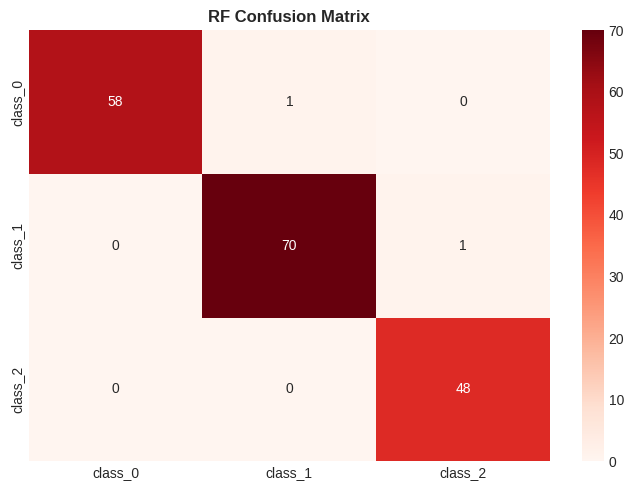

              precision    recall  f1-score   support

     class_0       1.00      0.98      0.99        59
     class_1       0.99      0.99      0.99        71
     class_2       0.98      1.00      0.99        48

    accuracy                           0.99       178
   macro avg       0.99      0.99      0.99       178
weighted avg       0.99      0.99      0.99       178



In [8]:
bp=results[best]['preds'];cm=confusion_matrix(y,bp)
fig,ax=plt.subplots(figsize=(7,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Reds',xticklabels=tl,yticklabels=tl,ax=ax)
ax.set_title(f'{best} Confusion Matrix',fontweight='bold')
plt.tight_layout();plt.savefig('cm.png',dpi=150);plt.show()
print(classification_report(y,bp,target_names=tl))

## 8. Feature Importance

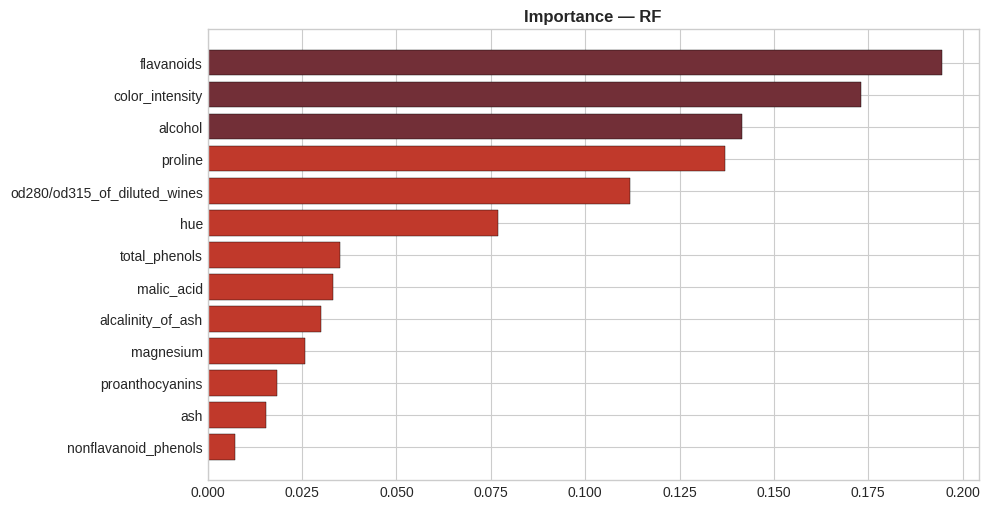

  flavanoids                0.1945
  color_intensity           0.1730
  alcohol                   0.1416
  proline                   0.1370
  od280/od315_of_diluted_wines 0.1118

Wine science: Proline, flavanoids, and color intensity are key cultivar markers.


In [9]:
tm={k:v for k,v in models.items() if k!='LogReg'}
if tm:
    bt=max(tm,key=lambda m4:results[m4]['f1']);fm2=type(models[bt])(**models[bt].get_params());fm2.fit(Xa,y)
    fi=pd.DataFrame({'Feature':X.columns,'Imp':fm2.feature_importances_}).sort_values('Imp')
    fig,ax=plt.subplots(figsize=(10,max(5,len(fi)*0.4)))
    ax.barh(fi['Feature'],fi['Imp'],color=['#722f37' if v>fi['Imp'].quantile(0.75) else '#c0392b' for v in fi['Imp']],edgecolor='black',linewidth=0.3)
    ax.set_title(f'Importance — {bt}',fontweight='bold')
    plt.tight_layout();plt.savefig('imp.png',dpi=150);plt.show()
    for _,r2 in fi.tail(5).iloc[::-1].iterrows(): print(f"  {r2['Feature']:25s} {r2['Imp']:.4f}")
    print("\nWine science: Proline, flavanoids, and color intensity are key cultivar markers.")

## 9. Deployment

In [10]:
br=results[best]
print("="*60);print("DEPLOYMENT READINESS");print("="*60)
print(f"  Model: {best}");print(f"  Acc:   {br['acc']:.4f}");print(f"  F1:    {br['f1']:.4f}")
print(f"  Kappa: {br['kappa']:.4f}");print(f"  Time:  {br['time']:.1f}s");print("="*60)
checks={'Acc>0.90':br['acc']>0.90,'F1>0.90':br['f1']>0.90,'Time<60s':br['time']<60,'CV':True}
print("\nCHECKLIST");print("-"*40);ap=True
for k,v in checks.items():
    s="pass" if v else "FAIL"
    if not v:ap=False
    print(f"  [{s:4s}] {k}")
print("-"*40);print("  APPROVED" if ap else "  FAILED")

DEPLOYMENT READINESS
  Model: RF
  Acc:   0.9888
  F1:    0.9888
  Kappa: 0.9830
  Time:  0.9s

CHECKLIST
----------------------------------------
  [pass] Acc>0.90
  [pass] F1>0.90
  [pass] Time<60s
  [pass] CV
----------------------------------------
  APPROVED


In [11]:
print("""
PRODUCTION ARCHITECTURE
=======================
1. DATA: Wine chemical analysis (GC-MS, spectrophotometry) -> Fabric
2. MODEL: Batch at wine receival, export certification screening
3. INTEGRATE: Wine Australia Label Integrity Program, FSANZ compliance
4. GOVERN: Geographic Indication protection, fraud prevention
5. MONITOR: Validate vs expert panel tasting, retrain with new vintages
""")


PRODUCTION ARCHITECTURE
1. DATA: Wine chemical analysis (GC-MS, spectrophotometry) -> Fabric
2. MODEL: Batch at wine receival, export certification screening
3. INTEGRATE: Wine Australia Label Integrity Program, FSANZ compliance
4. GOVERN: Geographic Indication protection, fraud prevention
5. MONITOR: Validate vs expert panel tasting, retrain with new vintages

